# PROJECT TITLE: Customer Churn Analysis and Prediction

## PROJECT OVERVIEW:

**The project aims to analyze customer churn in a telecommunications company and develop predictive models to identify at-risk customers.**\
**The ultimate goal is to provide actionable insights and recommendations to reduce churn and improve customer retention.**

# Tasks 1: Data Preparation

#### **Description:**
- Load and preprocess the dataset, addressing missing values, and encoding categorical variables for machine learning readiness.

#### **Skills:**
- Data preprocessing techniques
- Handling missing values
- Categorical variable encoding

**Loading Dataset**

In [89]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [62]:
df = pd.read_csv('Telco_Customer_Churn_Dataset  (1).csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Check dataset info by seeing the Datatype while looking out for missing values**

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [64]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**No missing values**

In [65]:
pd.set_option('display.max_columns', None)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### **PREPROCESSING**

To start with, conversion of `TotalCharges` column from string to numeric

In [66]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Handling missing values that occured during conversion of `TotalCharges` column**

In [68]:
df[df['TotalCharges'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [69]:
df[df['tenure'] == 0]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [70]:
df['TotalCharges'].fillna(0, inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


C:\Users\SBMNucopia\AppData\Local\Temp\ipykernel_15048\3534027529.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


Apparently, the `TotalCharges` is the multiplication of `tenure` by `MonthlyCharges`

After conversion from string to numeric, 0s were turned to NaN hence later filled with 0 using the fillna function

In [71]:
# Checking for Class Imbalance in the Target variable

df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [72]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043.000000,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,NaN,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,2279.734304,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,2266.794470,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,0.000000,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,398.550000,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1394.550000,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,3786.600000,NaN


#

# Tasks 2: Feature Selection

#### **Description:**
- Identify and select relevant features(attributes) influencing churn prediction,such as contract type, monthly charges,and tenure.

#### **Skills:**
- Feature relevance analysis
- Domain knowledge for identifying influential attributes
#

In [73]:
df1 = df.copy()

In [74]:
from sklearn.preprocessing import LabelEncoder

cat_col = df1.select_dtypes(include='object').columns
le = LabelEncoder()

for c in cat_col:
    df1[c] = le.fit_transform(df1[c])

df1.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,3962,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,2564,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,5535,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,6511,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

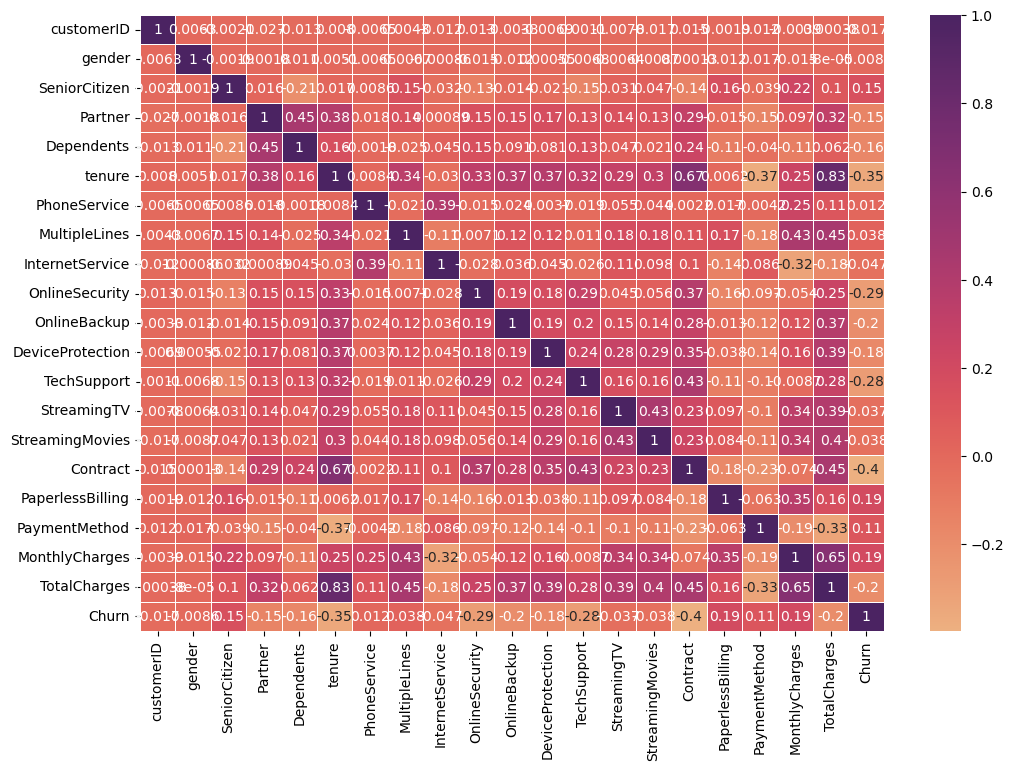

In [76]:
corr = df_corr.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='flare', lw=.5)
plt.show()


**Strongest predictors of Churn:**

- Contract $(-0.44) →$ Customers on month-to-month contracts are more likely to churn.
- Tenure  $(-0.35) →$ Longer tenure → less churn.
- TechSupport $(-0.28)$, OnlineSecurity $(-0.29) →$ Lack of these services means higher churn.
- Dependents $(-0.20) →$ Having dependents reduces churn likelihood.

**Weak or misleading correlations:**
-  CustomerID ≈ 0 → No meaningful link to churn.
- Gender ≈ 0 → No meaningful link to churn.

**High Inter-Variable Correlations *(Multicollinearity Risk)***

| Varaible Pair | Correlation |
|---|---|
| Total charges & tenure | 0.83 |
| Contract & tenure | 0.67 |
| Monthly charges & Total charges | 0.65 |


In [77]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["feature"] = df_corr.columns

vif["VIF"] = [variance_inflation_factor(df_corr.values, i) for i in range(len(df_corr.columns))]
vif

,feature,VIF
0,customerID,3.703802
1,gender,1.961374
2,SeniorCitizen,1.373269
3,Partner,2.822358
4,Dependents,1.965430
5,tenure,15.402382
6,PhoneService,15.307662
7,MultipleLines,2.758418
8,InternetService,4.383765
9,OnlineSecurity,2.269605


We used the above VIF to confirm the Multicollinearity and to determine which of the variable to that's to be dropped.

Since `TotalCharges` is the product of `MonthlyCharges` and `tenure` it is then reasonable to drop it. Hence the below code fir dropping 3 variables.

In [78]:
df1.drop(columns=['customerID', 'gender', 'TotalCharges'], axis=1, inplace=True)

In [79]:
df1.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,0
1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,0
2,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,1
3,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,0
4,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,1


In [80]:
df1.shape

(7043, 18)

# 

# Tasks 3: Split Data for Training and Testing

#### **Description:**
- Divide the data into training *(80%)* and testing *(20%)* sets for model training and evaluation, ensuring a representative split.

#### **Skills:**
- Data splitting methodologies
- Understanding of training/testing dataset requirements

#

In [81]:
from sklearn.model_selection import train_test_split

In [82]:
X = df1.drop('Churn', axis=1)
y = df1['Churn']

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=111)

# stratify=y due to class imbalance in target, y

In [84]:
print('X Training Shape:', X_train.shape)
print('y Training Shape:', y_train.shape)
print('X Testing Shape:', X_test.shape)
print('y Testing Shape:', y_test.shape)

X Training Shape: (5634, 17)
y Training Shape: (5634,)
X Testing Shape: (1409, 17)
y Testing Shape: (1409,)


# 
# Tasks 4: Model Selection

#### **Description:**
- Choose a suitable binary classification algorithm, considering options like logistic regression, decision trees, random forests, or gradient boosting.

#### **Skills:**
- Understanding of binary classification algorithms
- Selection based on dataset characteristics
#

In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [86]:
models = dict(
    lr = LogisticRegression(class_weight='balanced', random_state=111),
    dt = DecisionTreeClassifier(random_state=111),
    rf = RandomForestClassifier(class_weight='balanced', random_state=111),
    gb = GradientBoostingClassifier(random_state=111),
    xgb = XGBClassifier(scale_pos_weight=2.77, random_state=111)
)

# We used the class_weight to handle the class imbalance in target

In [87]:
results = []

for name, model in models.items():
    pip = Pipeline([
        ('scaler', StandardScaler()),
        ('algo', model)
    ])
    pip.fit(X_train, y_train)
    pred = pip.predict(X_test)

    recall = recall_score(y_test, pred)
    precision = precision_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
            
    results.append({'Model': name, 'Recall': recall,
                             'Precision': precision, 'F1 Score': f1, 'Accuracy': accuracy})

    print(f'------------------ {name.upper()} RESULT ----------------')
    print(classification_report(y_test, pred))
    print('============ Confusion Matrix =============\n')
    print(confusion_matrix(y_test, pred), '\n')


------------------ LR RESULT ----------------
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409

============ Confusion Matrix =============

[[755 280]
 [ 72 302]] 

------------------ DT RESULT ----------------
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1035
           1       0.48      0.47      0.47       374

    accuracy                           0.72      1409
   macro avg       0.64      0.64      0.64      1409
weighted avg       0.72      0.72      0.72      1409

============ Confusion Matrix =============

[[842 193]
 [199 175]] 

------------------ RF RESULT ----------------
              precision    recall  f1-score   support

           0 

Beyond the metrics, we need to understand the numbers while taking into account that **our goal is to reduce churn**

In predicting churn, we want to reduce False Negatives at the cost of increasing False Postives because the cost of a **False Negative** *(failing to identify a customer who actually leaves)* is typically much higher than a **False Positive** *(giving a discount or sending a retention email to someone who wasn't going to leave)*.

**Recall:** How many of the actual churners did we catch?. <br>
**Precision:** How many of our predicted churners actually left? (Usually lower with weights).

In the above analysis, **Logistic Regression** and **XGBoost** had the highest recall with 81% and 69% respectively hence will be chosen for finetuning.

# 
# Tasks 5: Model Training

#### **Description:**
- Train the selected machine learning model using the training dataset. Utilize chosen features as input and "Churn" column as the target variable.

#### **Skills:**
- Model training techniques
- Data input-output mapping for training
#

In [88]:
updated_models = dict(
    lr = LogisticRegression(random_state=111),
    xgb = XGBClassifier(random_state=111)
)

In [94]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, fbeta_score

scorer = make_scorer(fbeta_score, beta=2)

param_grids = {
    'lr': {
        'C': [0.001, 0.01, 0.1, 1, 10],
        'class_weight': ['balanced', [{0:1, 1:w} for w in [1, 2, 2.77, 4]]]
    },
    'xgb': {
        'scale_pos_weight': [1, 2.77, 5],
        'max_depth': [3, 6, 9],
        'learning_rate': [0.01, 0.1]
    }
}

results = {}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in updated_models.items():
    print(f"Searching for best {name.upper()}...")
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        scoring=scorer,
        cv=cv_strategy,
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    results[name] = grid.best_estimator_
    print(f"Best {name} F2-Score: {grid.best_score_:.4f}")
    print(grid.best_params_)

Searching for best LR...
Best lr F2-Score: 0.7164
{'C': 1, 'class_weight': 'balanced'}
Searching for best XGB...
Best xgb F2-Score: 0.7484
{'learning_rate': 0.1, 'max_depth': 3, 'scale_pos_weight': 5}


In [95]:
final_models = dict(
    lr = LogisticRegression(class_weight='balanced', C=1, random_state=111),
    xgb = XGBClassifier(scale_pos_weight=5, learning_rate=0.1, max_depth=3, random_state=111)
)

In [96]:
final_results = []

for name, model in final_models.items():
    pip = Pipeline([
        ('scaler', StandardScaler()),
        ('algo', model)
    ])
    pip.fit(X_train, y_train)
    pred = pip.predict(X_test)

    recall = recall_score(y_test, pred)
    precision = precision_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
            
    final_results.append({'Model': name, 'Recall': recall,
                             'Precision': precision, 'F1 Score': f1, 'Accuracy': accuracy})

    print(f'------------------ {name.upper()} Classification REPORT ----------------')
    print(classification_report(y_test, pred))
    print('============ Confusion Matrix =============\n')
    print(confusion_matrix(y_test, pred), '\n')


------------------ LR Classification REPORT ----------------
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409

============ Confusion Matrix =============

[[755 280]
 [ 72 302]] 

------------------ XGB Classification REPORT ----------------
              precision    recall  f1-score   support

           0       0.94      0.60      0.74      1035
           1       0.45      0.89      0.60       374

    accuracy                           0.68      1409
   macro avg       0.69      0.75      0.67      1409
weighted avg       0.81      0.68      0.70      1409

============ Confusion Matrix =============

[[626 409]
 [ 40 334]] 



# 
# Tasks 6: Model Evaluation

#### **Description:**
- Assess the model's performance on the testing dataset using metrics like accuracy, precision, recall, F1-score, and ROC-AUC

#### **Skills:**
- Model evaluation metrics understanding
- Interpretation of evaluation results
#

### Churn Prediction Model Assessment: LR vs. XGBoost

Given the objective to prioritize **Recall** *(minimizing False Negatives)* to ensure we catch as many potential churners as possible, here is the assessment:

| Metric | Logistic Regression | XGBoost | Implications for Churn |
| :--- | :--- | :--- | :--- |
| **Recall (Class 1)** | 0.81 | **0.89** | **XGBoost catches 89% of churners**, missing only 40. |
| **Precision (Class 1)** | **0.52** | 0.45 | LR is more "accurate" when it predicts churn, but misses more people. |
| **False Negatives** | 72 | **40** | **XGBoost is safer:** 32 fewer customers leave without being flagged. |
| **False Positives** | **280** | 409 | XGBoost triggers more "unnecessary" retention efforts. |

---

### Strategic Interpretation

* **Winner: XGBoost.** In a churn context, the **40 False Negatives** from XGBoost are much more acceptable than the **72** from Logistic Regression. Failing to identify those 32 extra churners represents a direct loss of revenue.
* **Cost of Retention:** While XGBoost produces **409 False Positives** (sending retention offers to customers who weren't leaving), the cost of a discount or email is significantly lower than the total loss of a customer's lifetime value.
* **Operational Impact:** XGBoost provides the highest "safety net." Even though its **Precision (0.45)** is lower which implies that less than half of your flagged customers are actually leaving, it ensures that nearly **90% of the churn risk** is identified and addressed.

---

### Conclusion
**XGBoost is the superior model for this business case.** Its high Recall (0.89) aligns with the goal of aggressive retention, effectively trading a higher volume of marketing outreach (False Positives) for a significantly lower rate of customer loss (False Negatives).